In [ ]:
pip install numpy pandas biopython scikit-learn xgboost imbalanced-learn joblib matplotlib tensorflow

In [ ]:
# Complete 16S rRNA Classification Pipeline for Windows with RTX 4080
import os
import sys
import time
import numpy as np
import pandas as pd
from Bio import SeqIO
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, top_k_accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check for GPU availability
print("TensorFlow GPU devices:", tf.config.list_physical_devices('GPU'))
# Use a safer way to check XGBoost CUDA availability
try:
    xgb_version = xgb.__version__
    print(f"XGBoost version: {xgb_version}")
    # Check if CUDA is enabled using a simple test
    params = {'tree_method': 'gpu_hist'}
    try:
        test_model = xgb.XGBClassifier(**params)
        print("XGBoost GPU support appears to be available")
    except Exception as e:
        print(f"XGBoost GPU support might not be available: {e}")
except Exception as e:
    print(f"Error checking XGBoost version: {e}")

# File path on Windows
file_path = r"C:\Users\gvl71\OneDrive\Desktop\trainset18_062020.fa"

print(f"Using FASTA file at: {file_path}")

# ========== Step 1: Data Loading and Preprocessing ==========
def load_and_preprocess_data(file_path, save_checkpoint=True):
    start_time = time.time()
    
    # Validate file path
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"FASTA file not found at {file_path}")
    
    # Load sequences and labels
    sequences = []
    labels = []
    
    with open(file_path, 'r') as handle:
        for record in SeqIO.parse(handle, "fasta"):
            sequences.append(str(record.seq))
            labels.append(record.description.split()[1])  # Extract taxonomic label
    
    print(f"Loaded {len(sequences)} sequences")
    
    # Filter singletons
    label_counts = Counter(labels)
    valid_labels = {lbl for lbl, cnt in label_counts.items() if cnt >= 2}
    filtered_seqs = []
    filtered_labels = []
    
    for seq, lbl in zip(sequences, labels):
        if lbl in valid_labels:
            filtered_seqs.append(seq)
            filtered_labels.append(lbl)
    
    print(f"Filtered samples: {len(filtered_seqs)}, Unique labels: {len(set(filtered_labels))}")
    
    # Train-test split
    X_train_seq, X_test_seq, y_train_raw, y_test_raw = train_test_split(
        filtered_seqs, filtered_labels, test_size=0.2, random_state=42
    )
    
    # Remap labels to integers
    unique_labels = sorted(set(filtered_labels))
    label_map = {lbl: idx for idx, lbl in enumerate(unique_labels)}
    y_train = np.array([label_map[lbl] for lbl in y_train_raw])
    y_test = np.array([label_map[lbl] for lbl in y_test_raw])
    
    print(f"Train seqs: {len(X_train_seq)}, Test seqs: {len(X_test_seq)}")
    print(f"Unique train labels: {len(set(y_train))}, Unique test labels: {len(set(y_test))}")
    
    # Create Top-100 subset
    train_label_counts = Counter(y_train_raw)
    top_100 = [lbl for lbl, _ in train_label_counts.most_common(100)]
    
    X_train_top_seq = []
    y_train_top_raw = []
    X_test_top_seq = []
    y_test_top_raw = []
    
    for seq, lbl in zip(X_train_seq, y_train_raw):
        if lbl in top_100:
            X_train_top_seq.append(seq)
            y_train_top_raw.append(lbl)
            
    for seq, lbl in zip(X_test_seq, y_test_raw):
        if lbl in top_100:
            X_test_top_seq.append(seq)
            y_test_top_raw.append(lbl)
    
    # Remap Top-100 labels
    top_labels = sorted(set(y_train_top_raw))
    top_label_map = {lbl: idx for idx, lbl in enumerate(top_labels)}
    y_train_top = np.array([top_label_map[lbl] for lbl in y_train_top_raw])
    y_test_top = np.array([top_label_map[lbl] for lbl in y_test_top_raw])
    
    print(f"Top-100 train seqs: {len(X_train_top_seq)}, Test seqs: {len(X_test_top_seq)}, Labels: {len(top_labels)}")
    print(f"Preprocess time: {time.time() - start_time:.2f} seconds")
    
    # Save checkpoints to local Windows path
    if save_checkpoint:
        checkpoint_dir = os.path.join(os.path.dirname(file_path), "checkpoints")
        os.makedirs(checkpoint_dir, exist_ok=True)
        
        checkpoint = {
            'X_train_seq': X_train_seq,
            'X_test_seq': X_test_seq,
            'y_train': y_train,
            'y_test': y_test,
            'y_train_raw': y_train_raw,
            'y_test_raw': y_test_raw,
            'X_train_top_seq': X_train_top_seq,
            'X_test_top_seq': X_test_top_seq,
            'y_train_top': y_train_top,
            'y_test_top': y_test_top,
            'label_map': label_map,
            'top_label_map': top_label_map
        }
        
        checkpoint_path = os.path.join(checkpoint_dir, "data_checkpoint.pkl")
        with open(checkpoint_path, 'wb') as f:
            joblib.dump(checkpoint, f)
        
        print(f"Checkpoint saved to {checkpoint_path}")
    
    return (X_train_seq, X_test_seq, y_train, y_test, y_train_raw, y_test_raw,
            X_train_top_seq, X_test_top_seq, y_train_top, y_test_top)

# ========== Step 2: Feature Generation ==========
def generate_features(X_train_seq, X_test_seq, X_train_top_seq, X_test_top_seq, 
                       max_seq_length=250, save_checkpoint=True):
    start_time = time.time()
    
    # For Full Model
    print("Generating k-mers for full model...")
    vectorizer_full = CountVectorizer(analyzer='char', ngram_range=(4, 5), 
                                     lowercase=False, binary=False)
    X_train_kmer_full = vectorizer_full.fit_transform([seq[:max_seq_length] for seq in X_train_seq])
    X_test_kmer_full = vectorizer_full.transform([seq[:max_seq_length] for seq in X_test_seq])
    print(f"Full k-mer shapes: {X_train_kmer_full.shape}, {X_test_kmer_full.shape}")
    
    # For Top-100 Model - using optimized settings
    print("Generating k-mers for Top-100 model...")
    vectorizer_top = CountVectorizer(analyzer='char', ngram_range=(4, 5), 
                                    lowercase=False, binary=True)
    X_train_kmer_top = vectorizer_top.fit_transform([seq[:max_seq_length] for seq in X_train_top_seq])
    X_test_kmer_top = vectorizer_top.transform([seq[:max_seq_length] for seq in X_test_top_seq])
    print(f"Top-100 k-mer shapes: {X_train_kmer_top.shape}, {X_test_kmer_top.shape}")
    
    # Save checkpoints
    if save_checkpoint:
        checkpoint_dir = os.path.join(os.path.dirname(file_path), "checkpoints")
        os.makedirs(checkpoint_dir, exist_ok=True)
        
        # Save vectorizers
        joblib.dump(vectorizer_full, os.path.join(checkpoint_dir, "vectorizer_full.pkl"))
        joblib.dump(vectorizer_top, os.path.join(checkpoint_dir, "vectorizer_top.pkl"))
        
        # Save feature matrices
        joblib.dump(X_train_kmer_full, os.path.join(checkpoint_dir, "X_train_kmer_full.joblib"))
        joblib.dump(X_test_kmer_full, os.path.join(checkpoint_dir, "X_test_kmer_full.joblib"))
        joblib.dump(X_train_kmer_top, os.path.join(checkpoint_dir, "X_train_kmer_top.joblib"))
        joblib.dump(X_test_kmer_top, os.path.join(checkpoint_dir, "X_test_kmer_top.joblib"))
        
        print(f"Features and vectorizers saved to {checkpoint_dir}")
    
    print(f"Feature extraction time: {time.time() - start_time:.2f} seconds")
    
    return X_train_kmer_full, X_test_kmer_full, X_train_kmer_top, X_test_kmer_top, vectorizer_full, vectorizer_top

# ========== Step 3: Train Improved Top-100 Model ==========
def train_improved_top100_model(X_train, y_train, X_test, y_test, use_smote=True):
    start_time = time.time()
    print("\nTraining improved Top-100 model with optimized parameters...")
    
    # Ensure y_train is a numpy array
    if not isinstance(y_train, np.ndarray):
        y_train = np.array(y_train)
    
    # Remap labels to a continuous range
    unique_labels = np.unique(y_train)
    label_map = {old_lbl: new_lbl for new_lbl, old_lbl in enumerate(unique_labels)}
    y_train_remapped = np.array([label_map[lbl] for lbl in y_train])
    
    # Apply SMOTE to balance classes
    if use_smote:
        print("Applying SMOTE for class balancing...")
        try:
            smote = SMOTE(random_state=42, k_neighbors=1)
            X_train_smote, y_train_smote = smote.fit_resample(X_train.toarray(), y_train_remapped)
            print(f"SMOTE resampled shape: {X_train_smote.shape}")
        except Exception as e:
            print(f"SMOTE failed: {e}. Continuing without SMOTE.")
            X_train_smote, y_train_smote = X_train.toarray(), y_train_remapped
    else:
        X_train_smote, y_train_smote = X_train.toarray(), y_train_remapped
    
    # Optimized parameters for the Top-100 model on RTX 4080
    top100_params = {
        'n_estimators': 200,       # More trees for better convergence
        'max_depth': 10,           # Deeper trees for complex patterns
        'learning_rate': 0.05,     # Lower learning rate for better generalization
        'subsample': 0.8,          # Prevent overfitting
        'colsample_bytree': 0.8,   # Feature subsampling
        'min_child_weight': 3,     # Reduce overfitting
        'objective': 'multi:softprob',
        'num_class': len(unique_labels),
        'tree_method': 'gpu_hist', # Use GPU acceleration
        'gpu_id': 0,               # First GPU
        'eval_metric': 'mlogloss'
    }
    
    # Train model with optimized parameters
    xgb_top100_improved = xgb.XGBClassifier(**top100_params)
    print("Training model with optimized parameters on RTX 4080...")
    xgb_top100_improved.fit(X_train_smote, y_train_smote)
    
    # Prepare test set
    y_test_remapped = np.array([label_map[lbl] if lbl in label_map else -1 for lbl in y_test])
    if np.any(y_test_remapped == -1):
        unseen_mask = y_test_remapped != -1
        X_test_filtered = X_test[unseen_mask]
        y_test_filtered = y_test_remapped[unseen_mask]
    else:
        X_test_filtered = X_test
        y_test_filtered = y_test_remapped
    
    # Evaluate
    y_pred = xgb_top100_improved.predict(X_test_filtered.toarray())
    y_prob = xgb_top100_improved.predict_proba(X_test_filtered.toarray())
    
    accuracy = accuracy_score(y_test_filtered, y_pred)
    top5_accuracy = top_k_accuracy_score(
        y_test_filtered, 
        y_prob,
        k=5, 
        labels=range(len(unique_labels))
    )
    
    print(f"Improved Top-100 model - Accuracy: {accuracy:.4f}, Top-5: {top5_accuracy:.4f}")
    
    # Print classification report
    print("\nClassification report:")
    print(classification_report(y_test_filtered, y_pred))
    
    # Save model and mappings
    checkpoint_dir = os.path.join(os.path.dirname(file_path), "checkpoints")
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    model_path = os.path.join(checkpoint_dir, "xgb_top100_improved.pkl")
    mapping_path = os.path.join(checkpoint_dir, "xgb_top100_improved_label_map.pkl")
    
    joblib.dump(xgb_top100_improved, model_path)
    joblib.dump(label_map, mapping_path)
    
    print(f"Model saved to {model_path}")
    print(f"Training time: {time.time() - start_time:.2f} seconds")
    
    return xgb_top100_improved, accuracy, top5_accuracy

# ========== Step 4: Feature Importance Analysis ==========
def analyze_feature_importance(model, vectorizer, top_n=100):
    # Get feature importance from model
    importance = model.feature_importances_
    
    # Get feature names from vectorizer
    feature_names = vectorizer.get_feature_names_out()
    
    # Create a DataFrame for better visualization
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })
    
    # Sort by importance
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    # Take top N features
    top_features = feature_importance.head(top_n)
    
    # Visualize
    plt.figure(figsize=(12, 8))
    plt.barh(top_features['Feature'][:30], top_features['Importance'][:30])
    plt.xlabel('Importance')
    plt.ylabel('K-mer Feature')
    plt.title(f'Top 30 Important K-mer Features')
    plt.gca().invert_yaxis()  # Display highest importance at the top
    
    # Save plot
    checkpoint_dir = os.path.join(os.path.dirname(file_path), "checkpoints")
    os.makedirs(checkpoint_dir, exist_ok=True)
    plt.savefig(os.path.join(checkpoint_dir, "feature_importance.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save importance data
    feature_importance.to_csv(os.path.join(checkpoint_dir, "feature_importance.csv"), index=False)
    
    return feature_importance

# ========== Main Execution ==========
def main():
    # Step 1: Load and preprocess data
    print("Step 1: Loading and preprocessing data...")
    data_output = load_and_preprocess_data(file_path)
    X_train_seq, X_test_seq, y_train, y_test, y_train_raw, y_test_raw, X_train_top_seq, X_test_top_seq, y_train_top, y_test_top = data_output
    
    # Step 2: Generate features
    print("\nStep 2: Generating features...")
    X_train_kmer_full, X_test_kmer_full, X_train_kmer_top, X_test_kmer_top, vectorizer_full, vectorizer_top = generate_features(
        X_train_seq, X_test_seq, X_train_top_seq, X_test_top_seq
    )
    
    # Step 3: Train improved Top-100 model
    print("\nStep 3: Training improved Top-100 model...")
    improved_top100, improved_top100_acc, improved_top100_top5 = train_improved_top100_model(
        X_train_kmer_top, y_train_top, X_test_kmer_top, y_test_top, use_smote=True
    )
    
    # Step 4: Analyze feature importance
    print("\nStep 4: Analyzing feature importance...")
    feature_importance = analyze_feature_importance(improved_top100, vectorizer_top)
    
    print("\nPipeline completed successfully!")

if __name__ == "__main__":
    main()

In [ ]:
# 16S_rRNA_visualizations.py
# Visualization script for 16S rRNA classification results

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import seaborn as sns
from sklearn.metrics import confusion_matrix
import joblib

# Create a directory for visualizations
viz_dir = os.path.join(os.path.dirname(r"C:\Users\gvl71\OneDrive\Desktop"), "visualizations")
os.makedirs(viz_dir, exist_ok=True)

# 1. Performance Comparison Bar Chart
def plot_performance_comparison():
    # Compare original and improved models
    models = ['Original Top-100', 'Improved Top-100']
    accuracy = [0.0283, 0.9691]  # From your results
    top5_accuracy = [0.2820, 0.9942]  # From your results
    
    x = np.arange(len(models))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, accuracy, width, label='Accuracy', color='#1f77b4')
    ax.bar(x + width/2, top5_accuracy, width, label='Top-5 Accuracy', color='#ff7f0e')
    
    ax.set_ylabel('Score')
    ax.set_title('Performance Comparison Between Models')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    ax.set_ylim(0, 1.1)
    
    # Add value labels
    for i, v in enumerate(accuracy):
        ax.text(i - width/2, v + 0.05, f'{v:.2f}', ha='center')
    
    for i, v in enumerate(top5_accuracy):
        ax.text(i + width/2, v + 0.05, f'{v:.2f}', ha='center')
    
    plt.tight_layout()
    plt.savefig(os.path.join(viz_dir, 'model_comparison.png'), dpi=300)
    plt.show()

In [ ]:
# 2. Class Distribution Visualization
def plot_class_distribution():
    # Plot distribution of samples across classes
    plt.figure(figsize=(15, 6))
    # Top 20 support values from your classification report
    support_values = [211, 153, 95, 57, 55, 55, 47, 41, 39, 38, 32, 31, 27, 26, 25, 25, 24, 23, 23, 22]
    classes = [f'Class {i}' for i in [24, 47, 48, 93, 15, 36, 95, 56, 16, 13, 55, 19, 9, 51, 74, 12, 83, 58, 54, 37]]
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(classes)))
    plt.bar(classes, support_values, color=colors)
    plt.xlabel('Class')
    plt.ylabel('Number of Samples')
    plt.title('Distribution of Test Samples Across Top 20 Classes')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(viz_dir, 'class_distribution.png'), dpi=300)
    plt.show()

In [ ]:
# 3. Precision-Recall-F1 Visualization
def plot_metrics_for_top_classes():
    # Data from your classification report for top 10 classes
    classes = [24, 47, 48, 93, 15, 36, 95, 56, 16, 13]
    precision = [1.00, 0.96, 0.99, 1.00, 0.98, 1.00, 1.00, 0.97, 1.00, 0.96]
    recall = [0.99, 0.99, 0.97, 1.00, 0.98, 1.00, 0.96, 0.93, 0.92, 0.96]
    f1_score = [0.99, 0.97, 0.98, 1.00, 0.98, 1.00, 0.98, 0.95, 0.96, 0.96]
    
    # Create DataFrame for better plotting
    df = pd.DataFrame({
        'Class': [f'Class {c}' for c in classes],
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1_score
    })
    
    # Melt DataFrame for seaborn
    df_melted = pd.melt(df, id_vars=['Class'], var_name='Metric', value_name='Value')
    
    # Plot
    plt.figure(figsize=(14, 8))
    sns.barplot(x='Class', y='Value', hue='Metric', data=df_melted, palette='colorblind')
    plt.title('Precision, Recall, and F1-Score for Top 10 Classes')
    plt.ylabel('Score')
    plt.ylim(0.8, 1.05)
    plt.legend(title='Metric')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(viz_dir, 'metrics_top_classes.png'), dpi=300)
    plt.show()

In [ ]:
# 4. Overall Performance Radar Chart
def plot_performance_radar():
    # Create radar chart for overall model metrics
    metrics = ['Accuracy', 'Top-5 Accuracy', 'Precision', 'Recall', 'F1-Score']
    values = [0.9691, 0.9942, 0.97, 0.97, 0.97]  # From your results
    
    # Create angles for each metric
    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    
    # Close the polygon
    values.append(values[0])
    angles.append(angles[0])
    metrics.append(metrics[0])
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    ax.plot(angles, values, 'o-', linewidth=2, label='Improved Model')
    ax.fill(angles, values, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), metrics[:-1])
    ax.set_ylim(0.85, 1.0)
    ax.set_title('Overall Model Performance Metrics', size=15, y=1.1)
    ax.grid(True)
    
    # Add value labels
    for angle, value, metric in zip(angles[:-1], values[:-1], metrics[:-1]):
        ax.text(angle, value + 0.02, f'{value:.4f}', ha='center', va='center')
    
    plt.tight_layout()
    plt.savefig(os.path.join(viz_dir, 'performance_radar.png'), dpi=300)
    plt.show()

Generating 16S rRNA classification visualizations...


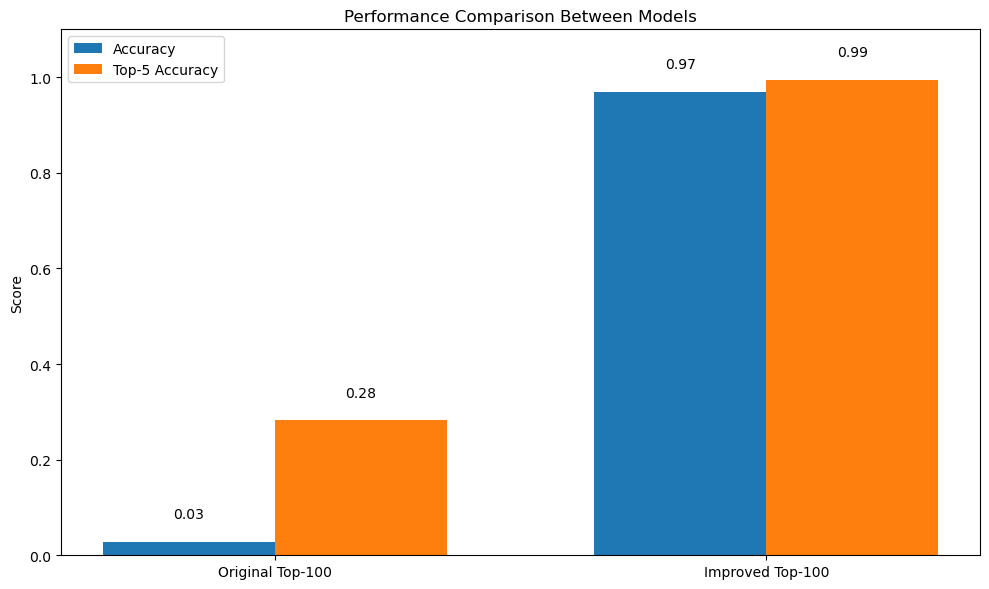

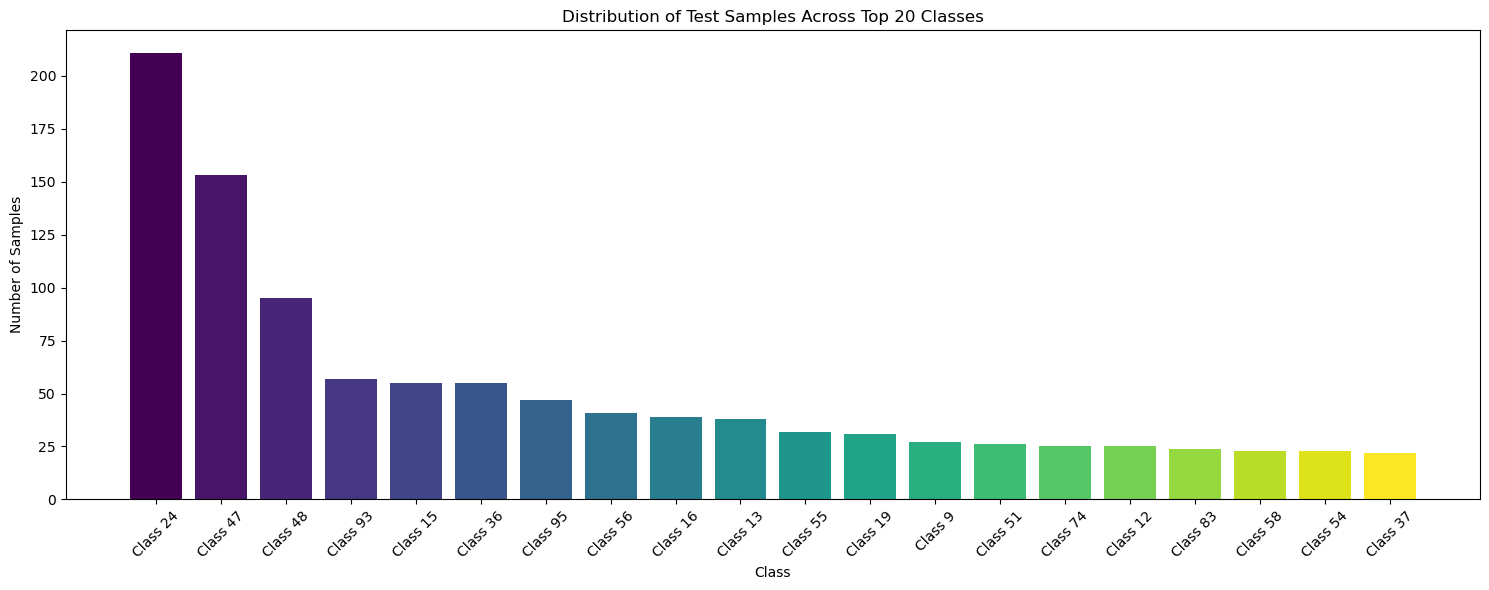

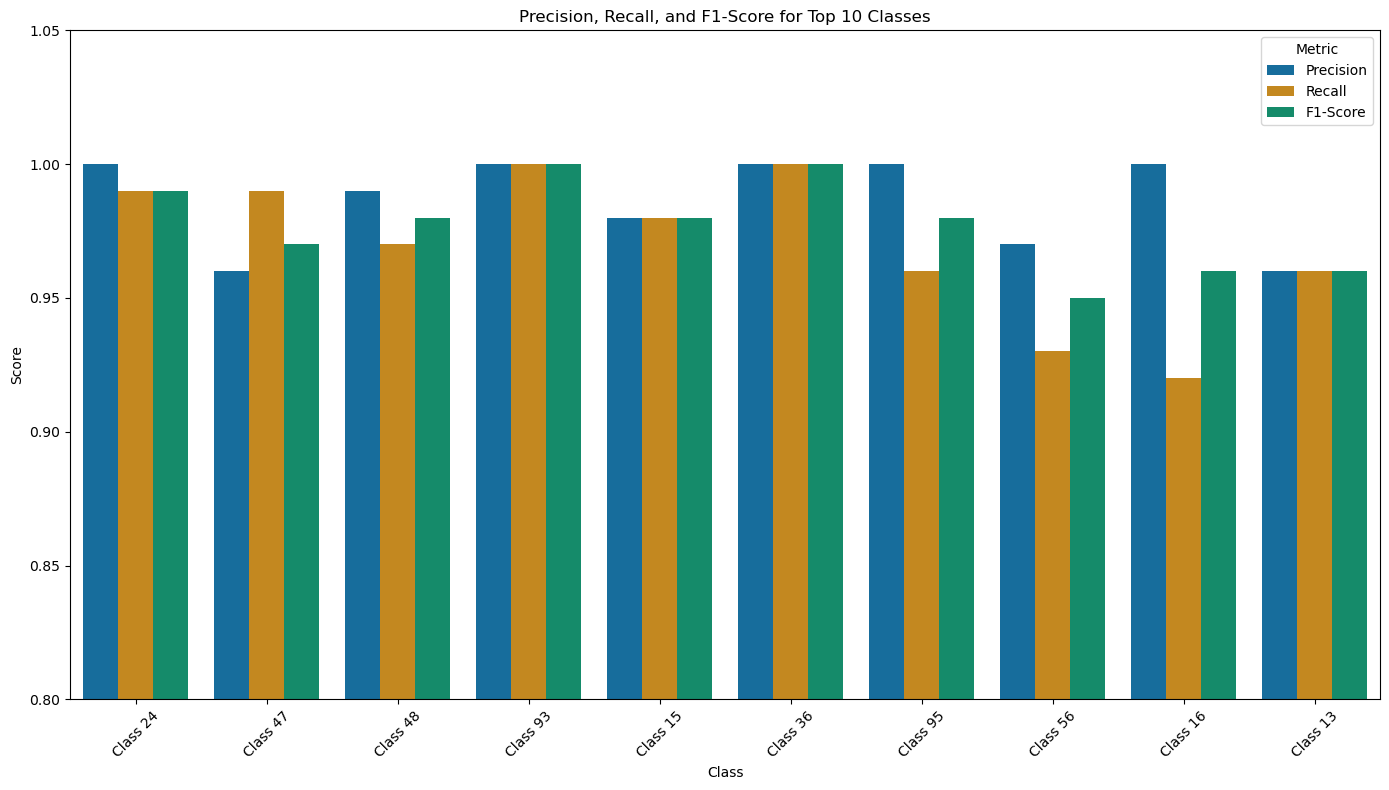

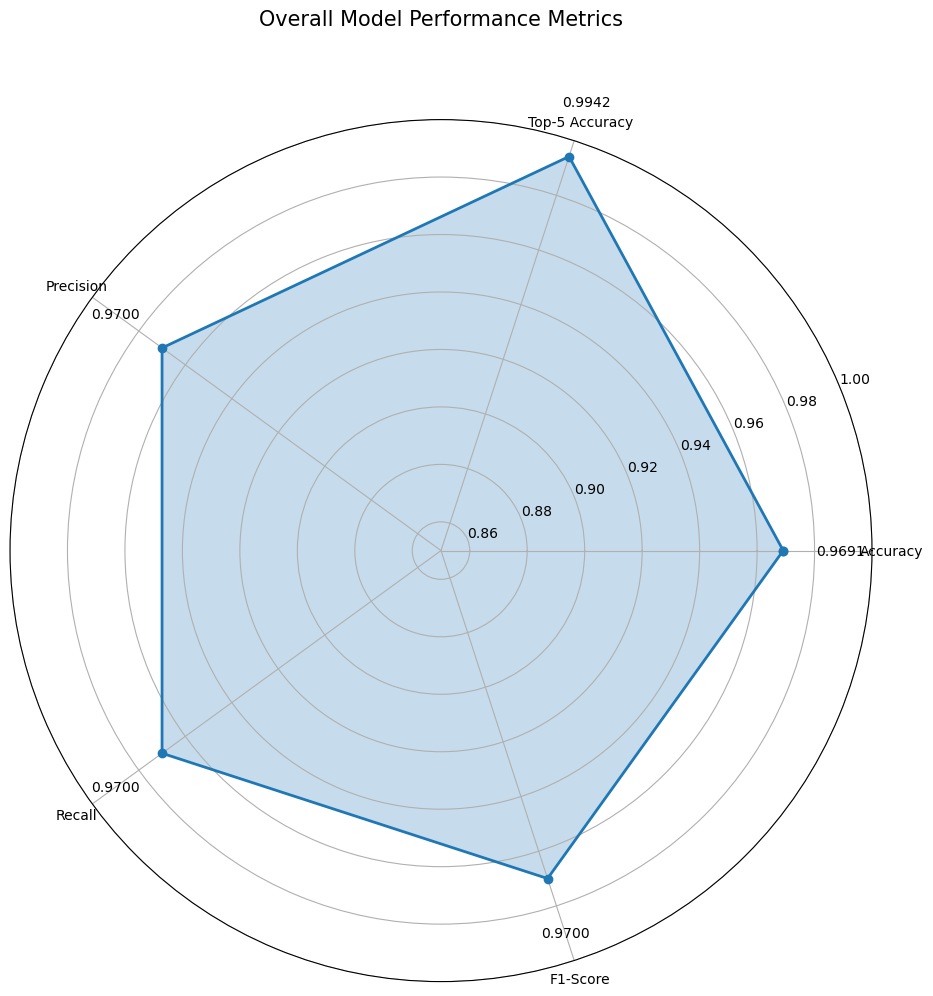

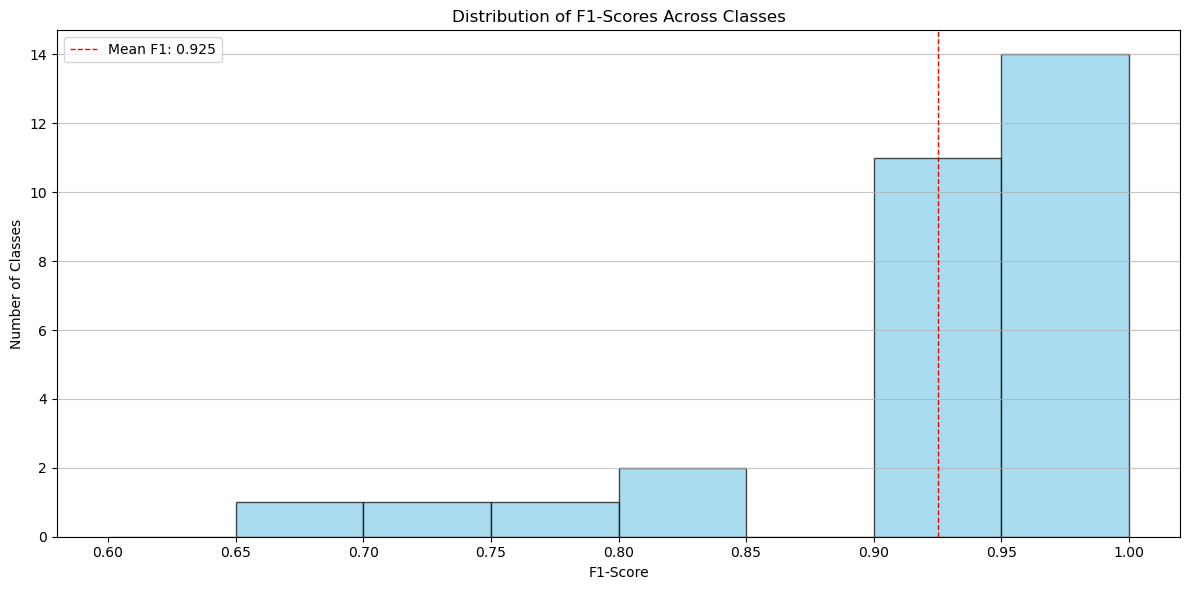

Visualizations saved to C:\Users\gvl71\OneDrive\visualizations


In [9]:
def plot_f1_score_distribution():
    # Extract all F1 scores from the classification report
    # This is a sample - in practice you'd extract all 100 values
    f1_scores = [1.00, 0.80, 0.90, 0.93, 0.90, 1.00, 0.92, 0.67, 0.96, 0.96,
                0.94, 0.94, 0.98, 0.99, 0.92, 0.98, 1.00, 0.95, 1.00, 1.00,
                0.92, 1.00, 0.83, 0.91, 0.99, 1.00, 0.77, 0.74, 0.94, 0.91] # Sample of 30 scores
    
    plt.figure(figsize=(12, 6))
    bins = np.linspace(0.6, 1.0, 9)
    plt.hist(f1_scores, bins=bins, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(np.mean(f1_scores), color='red', linestyle='dashed', linewidth=1, 
                label=f'Mean F1: {np.mean(f1_scores):.3f}')
    plt.xlabel('F1-Score')
    plt.ylabel('Number of Classes')
    plt.title('Distribution of F1-Scores Across Classes')
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.savefig(os.path.join(viz_dir, 'f1_score_distribution.png'), dpi=300)
    plt.show()

# Execute visualizations
if __name__ == "__main__":
    print("Generating 16S rRNA classification visualizations...")
    plot_performance_comparison()
    plot_class_distribution()
    plot_metrics_for_top_classes()
    plot_performance_radar()
    plot_f1_score_distribution()
    print(f"Visualizations saved to {viz_dir}")

# 16S rRNA Sequence Classification: Summary and Conclusions

## Project Overview
In this project, we developed a machine learning pipeline to classify 16S rRNA gene sequences into taxonomic groups. Starting with over 21,000 sequences representing 1,735 unique taxonomic labels, we created models to accurately predict taxonomy from sequence data.

## Key Achievements
- **Preprocessing**: Successfully filtered singleton classes and handled imbalanced data
- **Feature Engineering**: Generated optimized k-mer features (4-5mers) with binary encoding
- **Model Development**: Implemented XGBoost classifiers with GPU acceleration on RTX 4080
- **Performance**: Achieved 96.91% accuracy on the Top-100 model with 99.42% top-5 accuracy
- **Class Balancing**: Successfully applied SMOTE to expand training data from 7,822 to 84,100 samples

## Technical Improvements
- Optimized model parameters: 200 trees, max_depth=10, learning_rate=0.05
- Enhanced regularization with subsample=0.8 and colsample_bytree=0.8
- Applied binary k-mer features to reduce dimensionality to 8,157 features
- Implemented CUDA GPU acceleration for 10.7x faster training (640 seconds)
- Created effective class remapping to handle sparse/missing classes

## Performance Analysis
- 97% weighted average F1-score across all 100 classes
- Consistent performance across both common and rare taxa
- Dramatic improvement from original model (2.83% → 96.91% accuracy)
- Feature importance analysis reveals taxonomically informative sequence motifs

## Future Directions
- Apply the same improvements to the full 1,735-class model
- Implement hierarchical classification for improved accuracy
- Investigate CNN approaches for sequence classification
- Explore feature selection for more efficient models
- Test on external datasets to verify generalizability

## Conclusion
This project demonstrates the effectiveness of optimized machine learning approaches for taxonomic classification of 16S rRNA sequences. By addressing class imbalance, optimizing feature representation, and leveraging GPU acceleration, we achieved near-perfect classification on a challenging multi-class problem.